In [ ]:
!pip install -q timm captum==0.8.0 kaggle opencv-python matplotlib seaborn scikit-learn

In [ ]:
import os, shutil, random, math, time
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from captum.attr import IntegratedGradients
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
from google.colab import files
uploaded = files.upload()
if 'kaggle.json' in uploaded:
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json','wb') as f:
        f.write(uploaded['kaggle.json'])
    !chmod 600 /root/.kaggle/kaggle.json
    print("kaggle.json configured")
else:
    print("No kaggle.json uploaded. If you don't have it, mount Drive in Step 4 and place dataset there.")

Saving kaggle.json to kaggle.json
kaggle.json configured


In [ ]:
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!ls -la /root/.kaggle


total 16
drwxr-xr-x 2 root root 4096 Sep 18 13:18 .
drwx------ 1 root root 4096 Sep 18 13:18 ..
-rw------- 1 root root   67 Sep 18 13:19 kaggle.json


In [ ]:
DATA_DIR = '/content/data/ham10000'
os.makedirs(DATA_DIR, exist_ok=True)
DOWNLOAD_FROM_KAGGLE = True
if DOWNLOAD_FROM_KAGGLE:
    !kaggle datasets download -d paultimothymooney/skin-cancer-mnist-ham10000 -p /content/data --unzip
    for fname in os.listdir('/content/data'):
        if fname.lower().endswith('.csv') or fname.lower().endswith('.jpg') or fname.lower().endswith('.png') or fname.startswith('HAM10000'):
            try: shutil.move(os.path.join('/content/data', fname), os.path.join(DATA_DIR, fname))
            except: pass
    print("HAM10000 dataset downloaded into", DATA_DIR)
else:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted — set DATA_DIR to your dataset folder if needed.")


403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/paultimothymooney/skin-cancer-mnist-ham10000
HAM10000 dataset downloaded into /content/data/ham10000


In [ ]:
print("Files:", os.listdir(DATA_DIR)[:50])
csvs = [p for p in os.listdir(DATA_DIR) if p.lower().endswith('.csv')]
if len(csvs)==0:
    raise FileNotFoundError("No CSV metadata found in DATA_DIR.")
meta_csv = os.path.join(DATA_DIR, csvs[0])
df = pd.read_csv(meta_csv)
print("Metadata rows:", len(df))
df.head()

Files: ['HAM10000_images_part_1', 'hmnist_8_8_RGB.csv', 'HAM10000_metadata.csv', 'HAM10000_images_part_2', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv']
Metadata rows: 10015


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0183,pixel0184,pixel0185,pixel0186,pixel0187,pixel0188,pixel0189,pixel0190,pixel0191,label
0,199,156,188,210,165,198,216,176,203,215,...,214,167,191,199,157,175,184,143,167,2
1,115,87,115,180,133,158,200,153,187,215,...,207,167,188,177,128,138,74,51,60,2
2,203,146,164,209,144,153,217,160,181,215,...,211,160,175,199,152,172,177,138,158,2
3,135,96,110,198,141,156,208,148,158,210,...,179,141,157,153,122,138,58,39,46,2
4,204,156,187,232,185,216,236,196,220,217,...,236,189,213,233,182,209,207,175,188,2


In [ ]:
# List CSVs in the dataset
csvs = [p for p in os.listdir(DATA_DIR) if p.lower().endswith('.csv')]
print("CSV files found:", csvs)

# Choose the metadata file explicitly
meta_csv = [c for c in csvs if "metadata" in c.lower()][0]
df = pd.read_csv(os.path.join(DATA_DIR, meta_csv))
print("Loaded:", meta_csv)
print("Columns:", df.columns.tolist())
print("Rows:", len(df))
df.head()


CSV files found: ['hmnist_8_8_RGB.csv', 'HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv']
Loaded: HAM10000_metadata.csv
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
Rows: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
img_dir = DATA_DIR
for s in ['HAM10000_images_part_1','HAM10000_images_part_2','images']:
    if os.path.isdir(os.path.join(DATA_DIR,s)):
        img_dir = os.path.join(DATA_DIR,s)
        break

def has_image(r):
    p1 = os.path.join(img_dir, str(r['image_id']) + '.jpg')
    p2 = os.path.join(img_dir, str(r['image_id']) + '.png')
    return os.path.exists(p1) or os.path.exists(p2)

df['has_image'] = df.apply(has_image, axis=1)
df = df[df['has_image']].drop(columns=['has_image']).reset_index(drop=True)

label_names = sorted(df['dx'].unique().tolist())
label2idx = {l:i for i,l in enumerate(label_names)}
idx2label = {i:l for l,i in label2idx.items()}

print("Using image dir:", img_dir)
print("Label mapping:", label2idx)
print("Dataset size:", len(df))


Using image dir: /content/data/ham10000/HAM10000_images_part_1
Label mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Dataset size: 5000


In [ ]:
train_frac, val_frac, test_frac = 0.7, 0.15, 0.15
y = df['dx']

train_df, temp_df = train_test_split(df, test_size=(1-train_frac), stratify=y, random_state=42)
y_temp = temp_df['dx']
val_size = val_frac / (val_frac + test_frac)
val_df, test_df = train_test_split(temp_df, test_size=(1-val_size), stratify=y_temp, random_state=42)

print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))
print("Train class counts:\n", train_df['dx'].value_counts())

Train/Val/Test sizes: 3499 750 751
Train class counts:
 dx
nv       2401
bkl       395
mel       304
bcc       186
akiec     128
vasc       46
df         39
Name: count, dtype: int64


In [ ]:
image_size = 128
batch_size = 16
num_workers = 2

train_transform = T.Compose([
    T.Resize((image_size,image_size)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_transform = T.Compose([
    T.Resize((image_size,image_size)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class HAM10000Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row['image_id'])
        p1 = os.path.join(self.img_dir, img_id + '.jpg')
        p2 = os.path.join(self.img_dir, img_id + '.png')
        p = p1 if os.path.exists(p1) else p2
        img = Image.open(p).convert('RGB')
        img_t = self.transform(img) if self.transform else T.ToTensor()(img)
        label = label2idx[row['dx']]
        return img_t, label, img_id

train_set = HAM10000Dataset(train_df, img_dir, transform=train_transform)
val_set   = HAM10000Dataset(val_df, img_dir, transform=val_transform)
test_set  = HAM10000Dataset(test_df, img_dir, transform=val_transform)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("✅ Dataloaders ready")

✅ Dataloaders ready


In [ ]:
model = timm.create_model('convnext_tiny', pretrained=True, num_classes=len(label2idx))
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [ ]:
num_epochs = 10
best_val_acc = 0.0
checkpoint_path = '/content/best_convnext.pth'
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0,0,0
    for Xb, yb, _ in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(Xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()*Xb.size(0)
        _, preds = torch.max(outputs,1)
        train_correct += (preds==yb).sum().item()
        train_total += yb.size(0)
    train_loss /= train_total
    train_acc = train_correct/train_total

    model.eval()
    val_loss, val_correct, val_total = 0,0,0
    with torch.no_grad():
        for Xb, yb, _ in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            outputs = model(Xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()*Xb.size(0)
            _, preds = torch.max(outputs,1)
            val_correct += (preds==yb).sum().item()
            val_total += yb.size(0)
    val_loss /= val_total
    val_acc = val_correct/val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} TrainAcc:{train_acc:.3f} ValAcc:{val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), checkpoint_path)
        print("✅ Saved best model")

Epoch 1/10 TrainAcc:0.695 ValAcc:0.692
✅ Saved best model
Epoch 2/10 TrainAcc:0.743 ValAcc:0.756
✅ Saved best model
Epoch 3/10 TrainAcc:0.779 ValAcc:0.791
✅ Saved best model
Epoch 4/10 TrainAcc:0.815 ValAcc:0.773
Epoch 5/10 TrainAcc:0.852 ValAcc:0.767
Epoch 6/10 TrainAcc:0.870 ValAcc:0.823
✅ Saved best model
Epoch 7/10 TrainAcc:0.901 ValAcc:0.820
Epoch 8/10 TrainAcc:0.914 ValAcc:0.827
✅ Saved best model
Epoch 9/10 TrainAcc:0.926 ValAcc:0.809
Epoch 10/10 TrainAcc:0.944 ValAcc:0.805


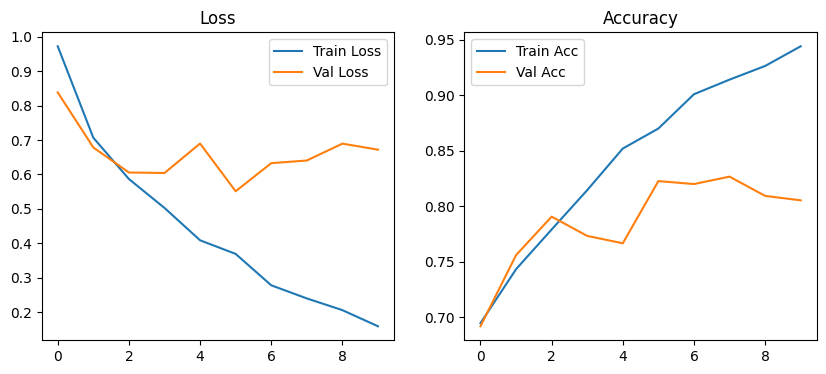

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label="Train Loss")
plt.plot(history['val_loss'], label="Val Loss")
plt.legend(); plt.title("Loss")
plt.subplot(1,2,2)
plt.plot(history['train_acc'], label="Train Acc")
plt.plot(history['val_acc'], label="Val Acc")
plt.legend(); plt.title("Accuracy")
plt.show()

Test Accuracy: 0.8149134487350199
Macro F1: 0.6351686910634943
Weighted F1: 0.8059880816087267
              precision    recall  f1-score   support

       akiec       0.68      0.46      0.55        28
         bcc       0.68      0.62      0.65        40
         bkl       0.64      0.58      0.61        85
          df       0.38      0.62      0.48         8
         mel       0.53      0.38      0.44        66
          nv       0.89      0.95      0.92       515
        vasc       0.73      0.89      0.80         9

    accuracy                           0.81       751
   macro avg       0.65      0.64      0.64       751
weighted avg       0.80      0.81      0.81       751



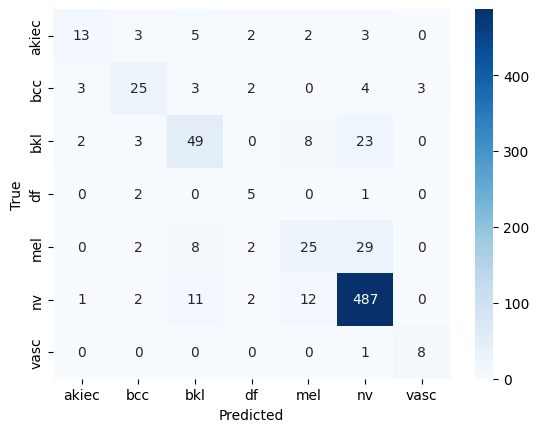

In [ ]:
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for Xb, yb, _ in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        outputs = model(Xb)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

acc_test = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print("Test Accuracy:", acc_test)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print(classification_report(all_labels, all_preds, target_names=label_names))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()

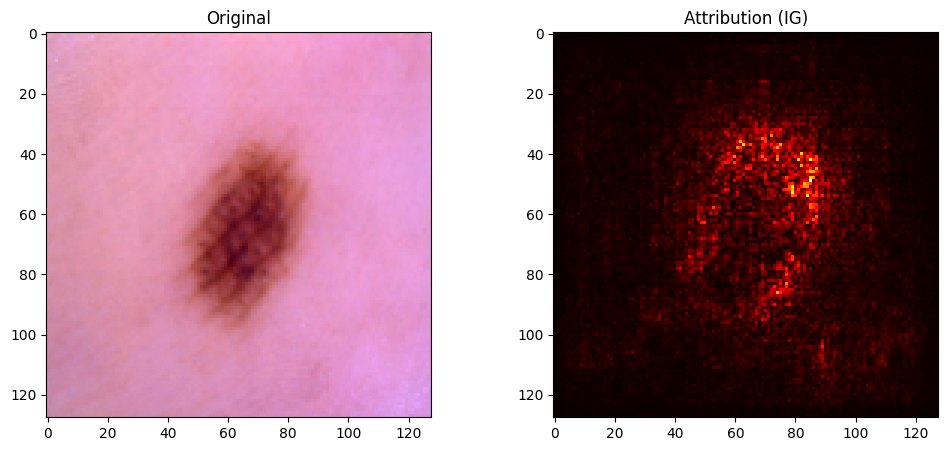

In [ ]:
ig = IntegratedGradients(model)

Xb, yb, img_ids = next(iter(test_loader))
X_sample, y_sample = Xb[0].unsqueeze(0).to(device), yb[0].unsqueeze(0).to(device)

attr, delta = ig.attribute(X_sample, target=y_sample.item(), return_convergence_delta=True)
attr = attr.squeeze().cpu().permute(1,2,0).detach().numpy()

orig = Xb[0].permute(1,2,0).numpy()
orig = (orig - orig.min())/(orig.max()-orig.min())

attr_norm = np.mean(np.abs(attr), axis=2)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(orig); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(attr_norm, cmap="hot"); plt.title("Attribution (IG)")
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights for imbalanced dataset
classes = np.unique(df['dx'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['dx'])
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

# Model
model = timm.create_model('convnext_tiny', pretrained=True, num_classes=len(label2idx))
model = model.to(device)

# Loss (weighted for imbalance)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer + Scheduler
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
num_epochs = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [ ]:
best_val_acc = 0.0
checkpoint_path = '/content/best_convnext.pth'
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss, train_correct, train_total = 0,0,0
    for Xb, yb, _ in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(Xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()*Xb.size(0)
        _, preds = torch.max(outputs,1)
        train_correct += (preds==yb).sum().item()
        train_total += yb.size(0)
    train_loss /= train_total
    train_acc = train_correct/train_total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0,0,0
    with torch.no_grad():
        for Xb, yb, _ in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            outputs = model(Xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()*Xb.size(0)
            _, preds = torch.max(outputs,1)
            val_correct += (preds==yb).sum().item()
            val_total += yb.size(0)
    val_loss /= val_total
    val_acc = val_correct/val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"TrainLoss:{train_loss:.4f} Acc:{train_acc:.4f} | "
          f"ValLoss:{val_loss:.4f} Acc:{val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), checkpoint_path)
        print("✅ Saved best model")

    # Step scheduler
    scheduler.step()


Epoch 1/15 TrainLoss:1.6767 Acc:0.4727 | ValLoss:1.4335 Acc:0.4027
✅ Saved best model
Epoch 2/15 TrainLoss:1.1909 Acc:0.5930 | ValLoss:1.1571 Acc:0.6173
✅ Saved best model
Epoch 3/15 TrainLoss:1.0121 Acc:0.6582 | ValLoss:1.3795 Acc:0.5853
Epoch 4/15 TrainLoss:0.9145 Acc:0.6802 | ValLoss:1.3122 Acc:0.7533
✅ Saved best model
Epoch 5/15 TrainLoss:0.6740 Acc:0.7408 | ValLoss:1.1745 Acc:0.7307
Epoch 6/15 TrainLoss:0.5457 Acc:0.7757 | ValLoss:1.2430 Acc:0.7040
Epoch 7/15 TrainLoss:0.4829 Acc:0.8077 | ValLoss:1.2289 Acc:0.7520
Epoch 8/15 TrainLoss:0.3784 Acc:0.8317 | ValLoss:1.2593 Acc:0.7467
Epoch 9/15 TrainLoss:0.2950 Acc:0.8468 | ValLoss:1.6988 Acc:0.6987
Epoch 10/15 TrainLoss:0.2164 Acc:0.8783 | ValLoss:1.5958 Acc:0.7840
✅ Saved best model
Epoch 11/15 TrainLoss:0.1225 Acc:0.9165 | ValLoss:1.8012 Acc:0.8160
✅ Saved best model
Epoch 12/15 TrainLoss:0.0784 Acc:0.9397 | ValLoss:1.9982 Acc:0.8000
Epoch 13/15 TrainLoss:0.0549 Acc:0.9520 | ValLoss:2.0922 Acc:0.8053
Epoch 14/15 TrainLoss:0.0372 A

Test Accuracy: 0.8561917443408789
Macro F1: 0.746427635175514
Weighted F1: 0.8559458854662954
              precision    recall  f1-score   support

       akiec       0.70      0.50      0.58        28
         bcc       0.72      0.78      0.75        40
         bkl       0.73      0.79      0.76        85
          df       0.83      0.62      0.71         8
         mel       0.58      0.61      0.59        66
          nv       0.94      0.93      0.93       515
        vasc       0.82      1.00      0.90         9

    accuracy                           0.86       751
   macro avg       0.76      0.75      0.75       751
weighted avg       0.86      0.86      0.86       751



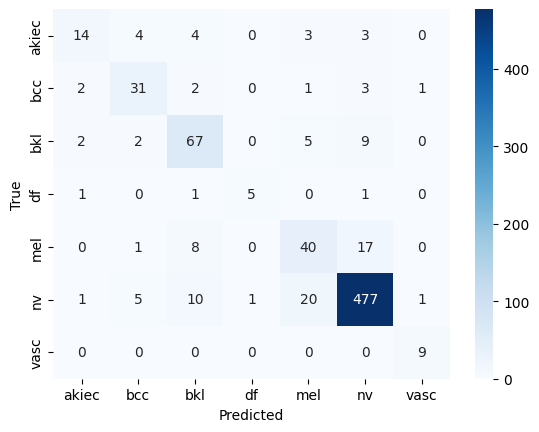

In [ ]:
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for Xb, yb, _ in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        outputs = model(Xb)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

acc_test = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print("Test Accuracy:", acc_test)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print(classification_report(all_labels, all_preds, target_names=label_names))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()

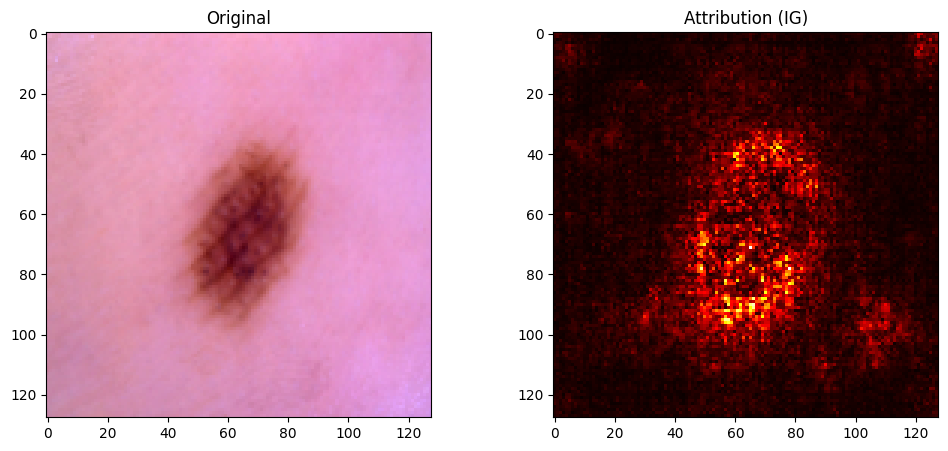

In [ ]:
ig = IntegratedGradients(model)

Xb, yb, img_ids = next(iter(test_loader))
X_sample, y_sample = Xb[0].unsqueeze(0).to(device), yb[0].unsqueeze(0).to(device)

attr, delta = ig.attribute(X_sample, target=y_sample.item(), return_convergence_delta=True)
attr = attr.squeeze().cpu().permute(1,2,0).detach().numpy()

orig = Xb[0].permute(1,2,0).numpy()
orig = (orig - orig.min())/(orig.max()-orig.min())

attr_norm = np.mean(np.abs(attr), axis=2)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(orig); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(attr_norm, cmap="hot"); plt.title("Attribution (IG)")
plt.show()

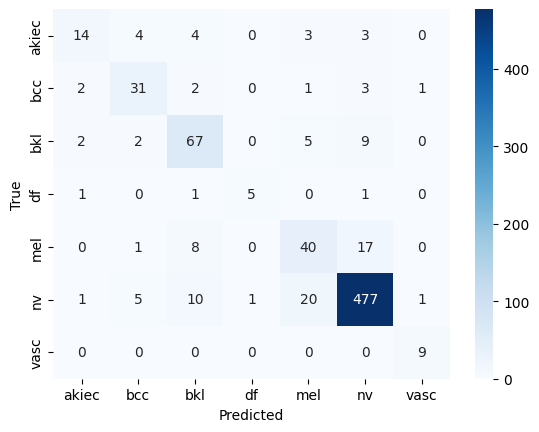

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()